This jupyter notebook will describe the process of doing EDA for the AUTO-MPG dataset. This data was first used in the 1983 American Statistical Association Exposition. It analyses mileage per galon performances of various cars. The aim is to perform the following tasks:
- Identify missing values.
- Estimate Skewness and Kurtosis.
- Correlation Heat Map.
- Scatter plot for different parameters.
- Replace categorical values with numerical values

# Import Libraries

In [33]:
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
data = pd.read_csv("Unit02 auto-mpg.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB


In [35]:
data.describe()


,mpg,cylinders,displacement,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


In [36]:
data.head()


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [37]:
data.shape

(398, 9)

In [38]:
# Check for null values in the dataset
print("Null values in each column:")
print(data.isnull().sum())

# Also check for '?' values which are sometimes used to represent missing data
print("\nQuestionmark ('?') values in each column:")
for column in data.columns:
    question_marks = (data[column].astype(str) == '?').sum()
    if question_marks > 0:
        print(f"{column}: {question_marks} values")



Null values in each column:
mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

Questionmark ('?') values in each column:
horsepower: 6 values


There are 6 records out of 398 that have missing values in the horsepower column that will be dropped.

In [39]:
data_preprocessed = data[data['horsepower'] != '?']
data_preprocessed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    object 
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   model year    392 non-null    int64  
 7   origin        392 non-null    int64  
 8   car name      392 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 30.6+ KB


# Skewness and Kurtosis
Since missing values have been removed, Skewness and Kurtosis will now be estimated.

In [40]:
data_preprocessed.skew(numeric_only=True), data_preprocessed.kurt(numeric_only=True)


(mpg             0.457092
 cylinders       0.508109
 displacement    0.701669
 weight          0.519586
 acceleration    0.291587
 model year      0.019688
 origin          0.915185
 dtype: float64,
 mpg            -0.515993
 cylinders      -1.398199
 displacement   -0.778317
 weight         -0.809259
 acceleration    0.444234
 model year     -1.167446
 origin         -0.841885
 dtype: float64)

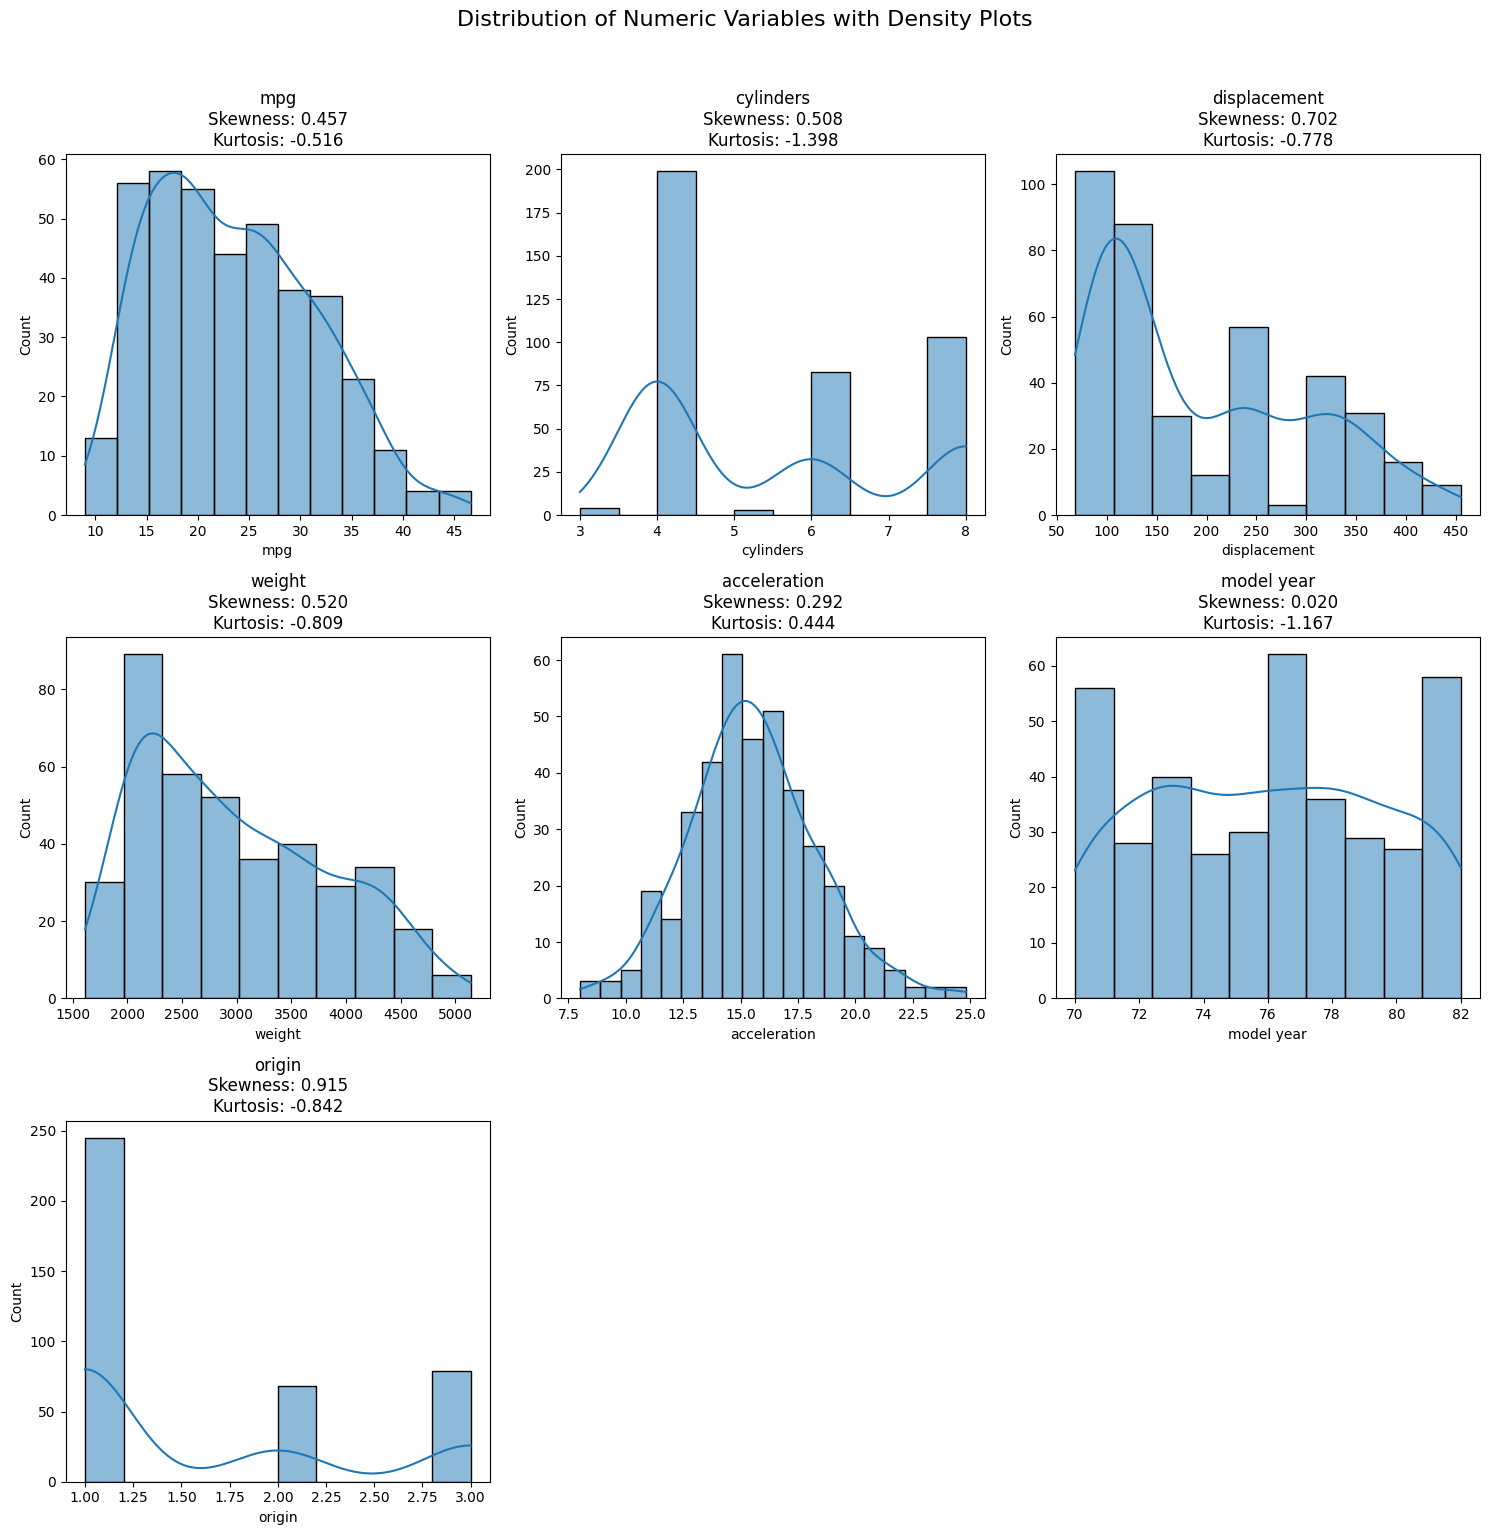

In [41]:
# Create subplots for all numeric columns
numeric_cols = ['mpg', 'cylinders', 'displacement', 'weight', 'acceleration', 'model year', 'origin']
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
fig.suptitle('Distribution of Numeric Variables with Density Plots', fontsize=16, y=1.02)

# Flatten axes for easier iteration
axes = axes.flatten()

# Plot histograms with density curves
for idx, col in enumerate(numeric_cols):
    # Histogram
    sns.histplot(data=data_preprocessed, x=col, kde=True, ax=axes[idx])
    axes[idx].set_title(f'{col}\nSkewness: {data_preprocessed[col].skew():.3f}\nKurtosis: {data_preprocessed[col].kurt():.3f}')

# Remove extra subplot
axes[-1].remove()
axes[-2].remove()

plt.tight_layout()
plt.show()



The skewness is positive for all variables, which indicates that the data has a longer tail on the right side. Mpg, Acceleration and Model year are fairly symmetrical (|skewness| < 0.5) while the other variables are moderately skewed.

When it comes to Kurtosis, all variables have a negative value except acceleration (0.44). This means that most variables have lighter tails (fewer outliers) than a normal distribution would have.

# Correlation Heatmap

A correlation heatmap is a graphical representation of a correlation matrix that shows the correlation coefficients between multiple variables using colors. One has beeen built for the auto-mpg data set.

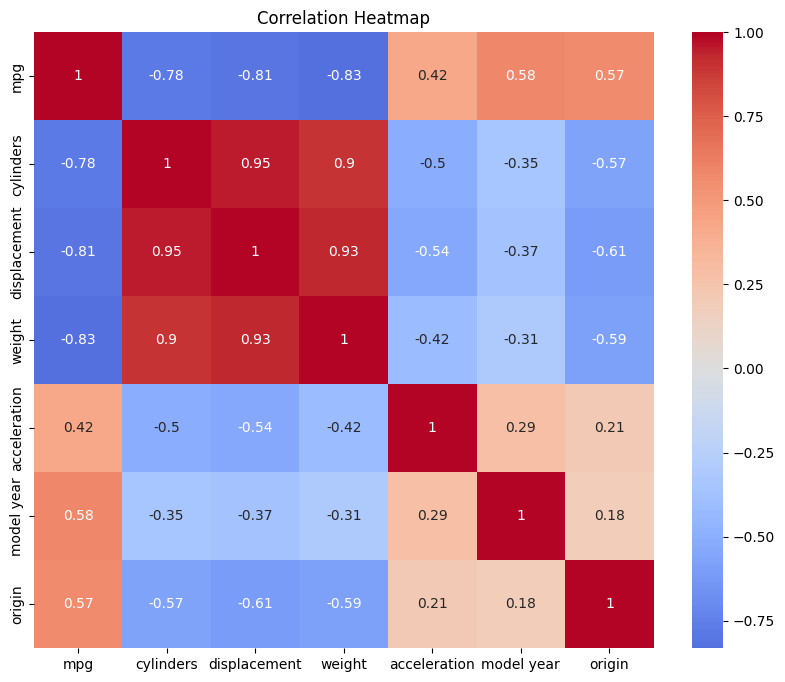

In [42]:
# Calculate correlation matrix
correlation_matrix = data_preprocessed.corr(numeric_only=True)

# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

There's a strong positive correlation between the cylinders, displacemenet and weight variables. At the same time, mpg has strong negative correlation with cylinders, displacement and weight. We will plot those 4 variables against each other to visualize the correlation.

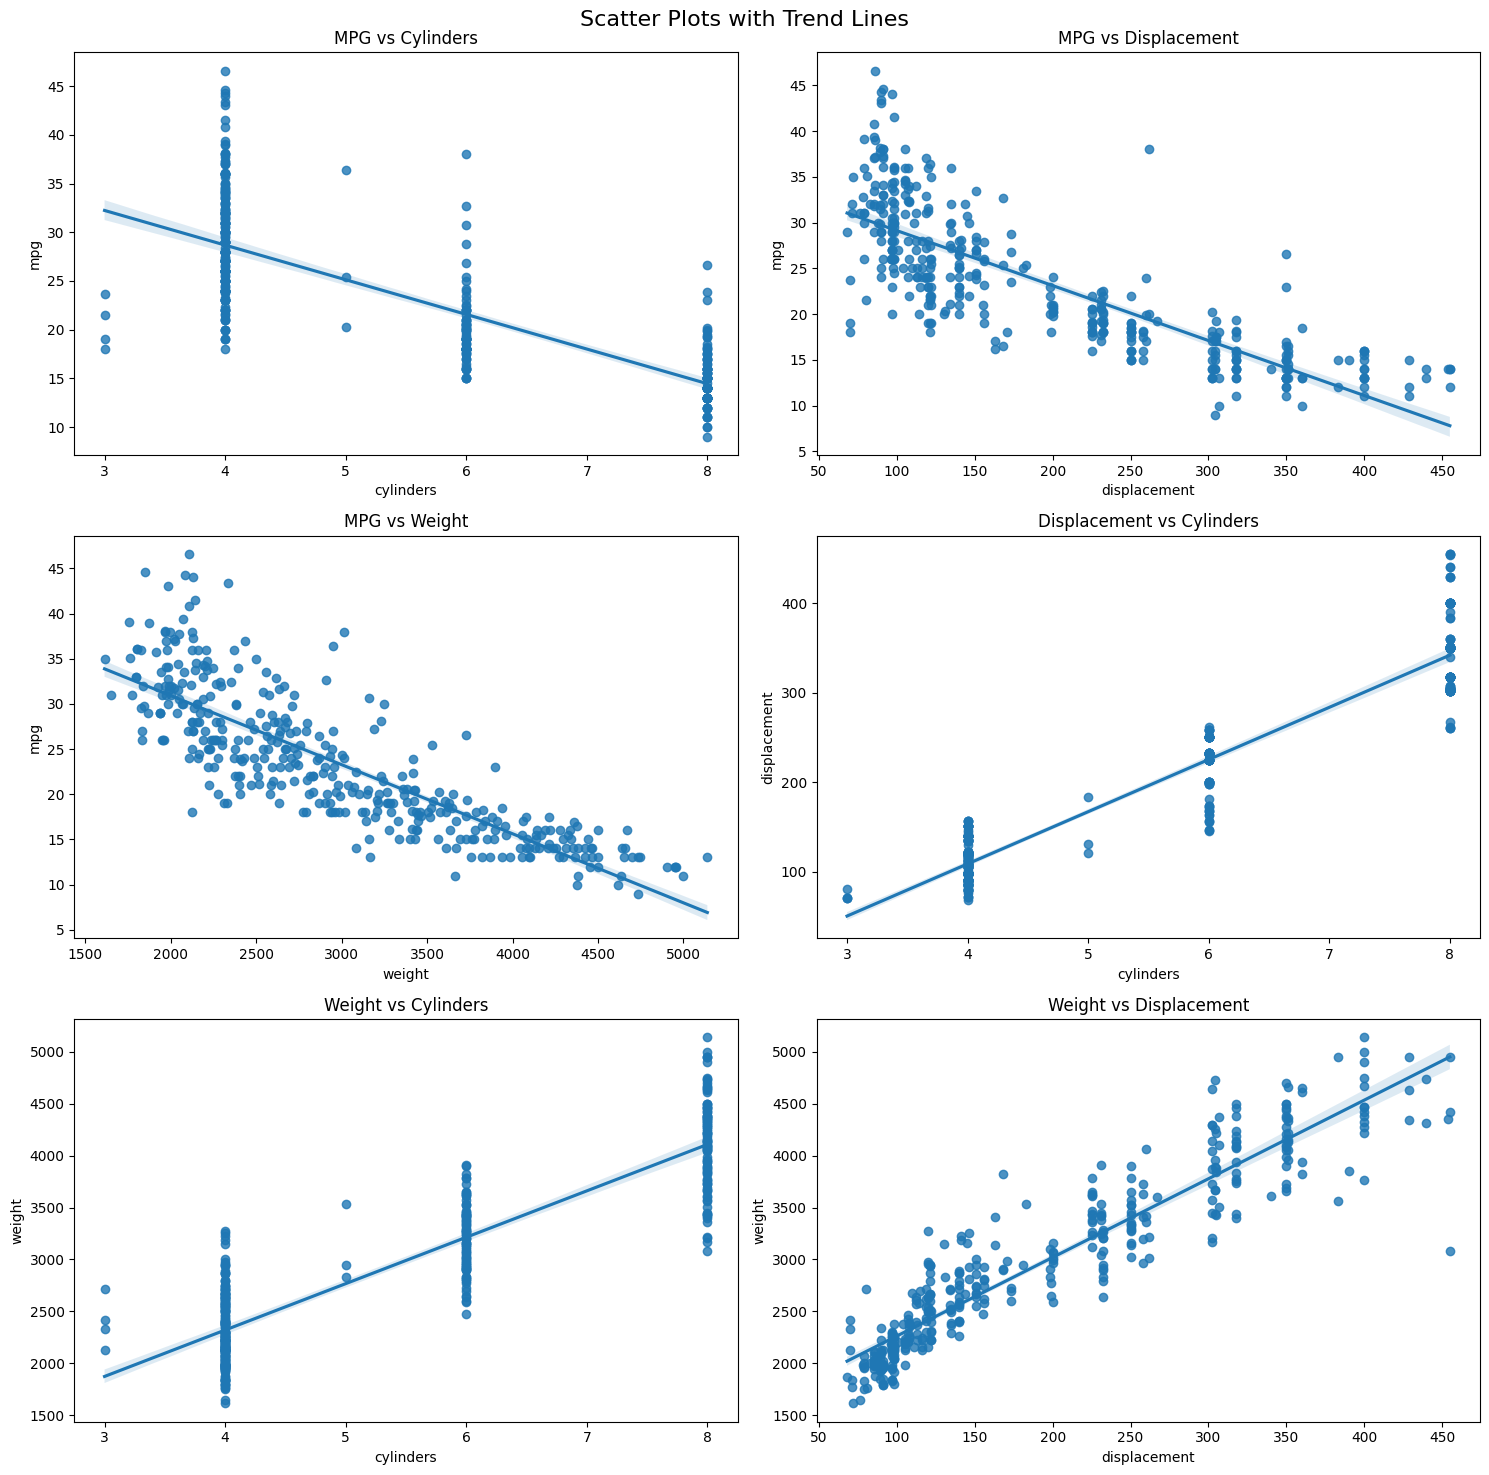

In [44]:
# Create a figure with multiple subplots for all combinations
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
fig.suptitle('Scatter Plots with Trend Lines', fontsize=16)

# Plot 1: MPG vs Cylinders with trend line
sns.regplot(data=data_preprocessed, x='cylinders', y='mpg', ax=axes[0,0])
axes[0,0].set_title('MPG vs Cylinders')

# Plot 2: MPG vs Displacement with trend line
sns.regplot(data=data_preprocessed, x='displacement', y='mpg', ax=axes[0,1])
axes[0,1].set_title('MPG vs Displacement')

# Plot 3: MPG vs Weight with trend line
sns.regplot(data=data_preprocessed, x='weight', y='mpg', ax=axes[1,0])
axes[1,0].set_title('MPG vs Weight')

# Plot 4: Displacement vs Cylinders with trend line
sns.regplot(data=data_preprocessed, x='cylinders', y='displacement', ax=axes[1,1])
axes[1,1].set_title('Displacement vs Cylinders')

# Plot 5: Weight vs Cylinders with trend line
sns.regplot(data=data_preprocessed, x='cylinders', y='weight', ax=axes[2,0])
axes[2,0].set_title('Weight vs Cylinders')

# Plot 6: Weight vs Displacement with trend line
sns.regplot(data=data_preprocessed, x='displacement', y='weight', ax=axes[2,1])
axes[2,1].set_title('Weight vs Displacement')

# Adjust layout
plt.tight_layout()
plt.show()

Analysis:
- Negative trends in the MPG relationships (as other variables increase, MPG decreases)
- Positive trends between weight, displacement, and cylinders (they tend to increase together)
- The confidence intervals will show how much uncertainty there is in these relationships